# 🏠 Fi Dari — Prédiction de Prix Immobilier (Tunisie)
## Pipeline complet : Data Cleaning → Feature Engineering → ML

**Dataset :** `fi_dari.csv` — 4 000 annonces immobilières (appartements + maisons/villas)
**Cible :** Prix de vente en dinars tunisiens (TND)

---
| Étape | Action |
|---|---|
| 1 | Suppression terrains & locations |
| 2 | Suppression colonnes inutiles |
| 3 | Parsing prix (TND, EUR→TND, anomalies) |
| 4 | Suppression lignes prix manquant |
| 5 | Outliers prix par type de bien |
| 6 | Nettoyage surface (typos, imputation) |
| 7 | Nettoyage rooms / bedrooms |
| 8 | Extraction ville depuis titre+description |
| 9 | Suppression doublons |
| 10 | Feature Engineering + Modélisation |

## 📦 1. Installation & Imports

In [ ]:
!pip install xgboost missingno --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings, re

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print('✅ Imports OK')

✅ Imports OK


## 📂 2. Chargement des données

In [ ]:
from google.colab import files
uploaded = files.upload()   # ← Uploadez fi_dari.csv ici

df_raw = pd.read_csv('fi_dari.csv')
print(f'✅ Chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')
print()
print('property_type    :', df_raw['property_type'].value_counts().to_dict())
print('transaction_type :', df_raw['transaction_type'].value_counts().to_dict())
df_raw.head(3)

Saving fi_dari.csv to fi_dari.csv
✅ Chargé : 4,000 lignes × 21 colonnes

property_type    : {'apartment': 3630, 'house': 370}
transaction_type : {'sale': 4000}


,id,title,subtitle,price,transaction_type,property_type,location_details,municipality,surface,rooms,bedrooms,bathrooms,features,poi,description,url,image_path,images_folder,images_count,scraped_at,last_updated
0,1,S2 en vente,Tunisie,360000 TND,sale,apartment,"{""raw"": ""Tunisie"", ""city"": ""Tunisie"", ""zone"": ...",Tunisie,NaN,2.00,NaN,NaN,{},{},Cet appartement est situé au rez-de-chaussée d...,https://www.mubawab.tn/fr/a/8294557/s2-en-vente,media\apartment\1\image_001.jpg,media\apartment\1,17,2026-02-18 09:17:27.187609,Unknown
1,2,S2 en vente,Tunisie,592000 TND,sale,apartment,"{""raw"": ""Tunisie"", ""city"": ""Tunisie"", ""zone"": ...",Tunisie,131.39,2.00,NaN,NaN,{},{},"Direct promoteur, spacieux appartement S2 en r...",https://www.mubawab.tn/fr/a/8303764/s2-en-vente,media\apartment\2\image_001.jpg,media\apartment\2,22,2026-02-18 09:17:48.807684,Unknown
2,3,S3 en vente,Tunisie,485000 TND,sale,apartment,"{""raw"": ""Tunisie"", ""city"": ""Tunisie"", ""zone"": ...",Tunisie,NaN,3.00,NaN,NaN,{},{},Appartement S3 occupant le deuxième et dernier...,https://www.mubawab.tn/fr/a/8302133/s3-en-vente,media\apartment\3\image_001.jpg,media\apartment\3,19,2026-02-18 09:18:05.01749,Unknown


## 🔍 3. Exploration Initiale (EDA Brute)

In [3]:
print('=== VALEURS MANQUANTES ===')
miss = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(1)
display(
    pd.DataFrame({'Manquant': miss, 'Pct (%)': miss_pct})
    .query('Manquant > 0').sort_values('Pct (%)', ascending=False)
)

=== VALEURS MANQUANTES ===


,Manquant,Pct (%)
bathrooms,4000,100.00
bedrooms,3277,81.90
surface,1862,46.60
rooms,593,14.80
description,335,8.40
image_path,38,1.00
price,29,0.70


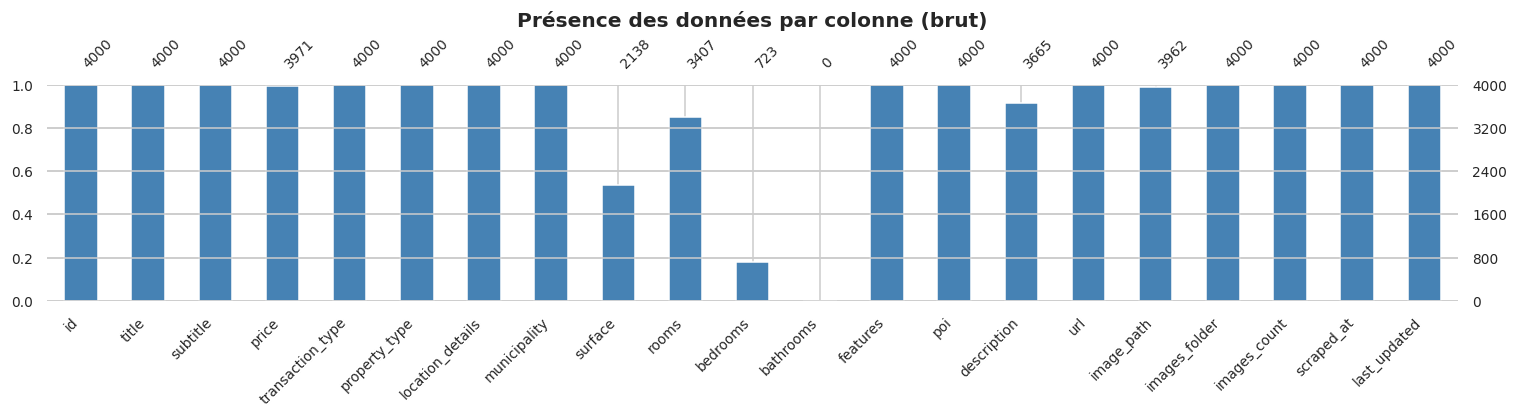

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
msno.bar(df_raw, ax=ax, color='steelblue', fontsize=9)
plt.title('Présence des données par colonne (brut)', fontweight='bold')
plt.tight_layout(); plt.show()

In [5]:
print('=== ANALYSE PRIX BRUT ===')
print(f"NaN                 : {df_raw['price'].isna().sum()}")
print(f"'Prix à consulter'  : {(df_raw['price']=='Prix à consulter').sum()}")
print(f"'30000' sans unité  : {(df_raw['price']=='30000').sum()} (anomalie → sera supprimé)")
print(f"En EUR              : {df_raw['price'].str.contains('EUR', na=False).sum()} (→ conversion ×3.37)")
print(f"En TND              : {df_raw['price'].str.contains('TND', na=False).sum()}")
print()
print('Top 20 valeurs prix :')
print(df_raw['price'].value_counts().head(20))

=== ANALYSE PRIX BRUT ===
NaN                 : 29
'Prix à consulter'  : 662
'30000' sans unité  : 304 (anomalie → sera supprimé)
En EUR              : 33 (→ conversion ×3.37)
En TND              : 2972

Top 20 valeurs prix :
price
Prix à consulter    662
30000               304
300000 TND           93
360000 TND           61
400000 TND           58
650000 TND           57
450000 TND           53
225000 TND           48
245000 TND           46
235000 TND           45
285000 TND           44
380000 TND           42
340000 TND           42
420000 TND           41
395000 TND           40
390000 TND           36
635000 TND           36
280000 TND           36
840000 TND           36
310000 TND           33
Name: count, dtype: int64


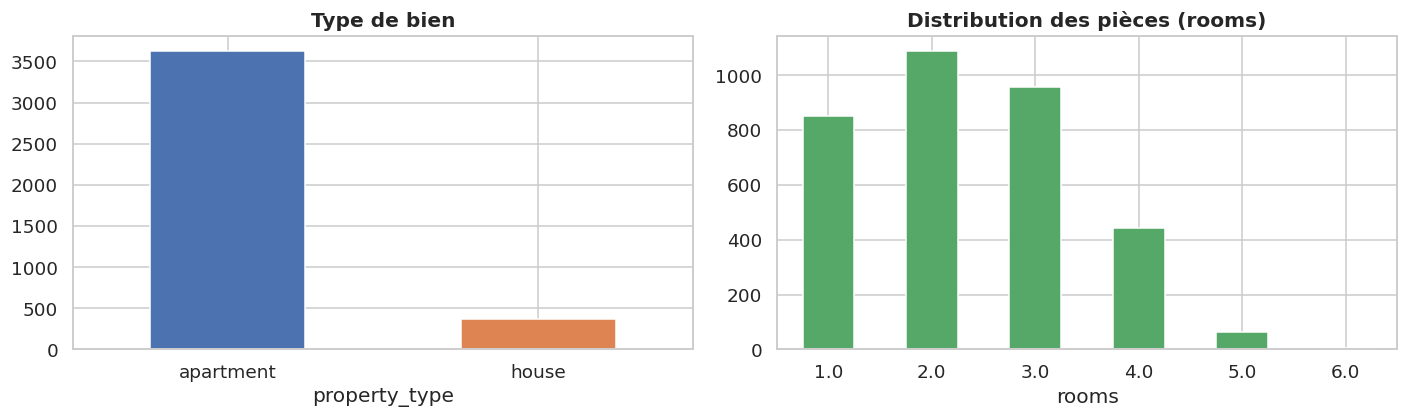

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_raw['property_type'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#4C72B0','#DD8452'], edgecolor='white')
axes[0].set_title('Type de bien', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

df_raw['rooms'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color='#55A868', edgecolor='white')
axes[1].set_title('Distribution des pièces (rooms)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 🧹 4. Prétraitement — Data Cleaning Complet

In [7]:
df = df_raw.copy()
stats = {'initial': len(df)}
print(f'▶ Début nettoyage : {len(df):,} lignes')

▶ Début nettoyage : 4,000 lignes


In [8]:
# ══════════════════════════════════════════════════
# ÉTAPE 1 — FILTRAGE MÉTIER
# Suppression terrains + locations
# ══════════════════════════════════════════════════

# 1a. Terrains
mask_land = df['property_type'] == 'land'
df = df[~mask_land]
stats['apres_land'] = len(df)
print(f'✅ Terrains supprimés      : {mask_land.sum():>5} lignes → {len(df):,} restantes')

# 1b. Locations (rent)
mask_rent = df['transaction_type'] == 'rent'
df = df[~mask_rent]
stats['apres_rent'] = len(df)
print(f'✅ Locations supprimées    : {mask_rent.sum():>5} lignes → {len(df):,} restantes')

print()
print('Distribution après filtrage :')
print('  property_type    :', df['property_type'].value_counts().to_dict())
print('  transaction_type :', df['transaction_type'].value_counts().to_dict())

✅ Terrains supprimés      :     0 lignes → 4,000 restantes
✅ Locations supprimées    :     0 lignes → 4,000 restantes

Distribution après filtrage :
  property_type    : {'apartment': 3630, 'house': 370}
  transaction_type : {'sale': 4000}


In [9]:
# ══════════════════════════════════════════════════
# ÉTAPE 2 — SUPPRESSION COLONNES INUTILES
# ══════════════════════════════════════════════════
cols_drop = [
    'subtitle',         # toujours 'Tunisie'
    'poi',              # JSON vide '{}'
    'features',         # '{}' ou 'rangement' — info dans bedrooms
    'url',              # identifiant web, pas de signal prédictif
    'image_path',       # chemin local
    'images_folder',    # chemin local
    'scraped_at',       # date de scraping
    'last_updated',     # toujours 'Unknown'
    'location_details', # JSON redondant — municipality toujours 'Tunisie'
    'transaction_type', # uniforme après filtrage (toujours 'sale')
]
df.drop(columns=cols_drop, inplace=True, errors='ignore')
print(f'✅ {len(cols_drop)} colonnes supprimées → {df.shape[1]} colonnes restantes')
print(df.columns.tolist())

✅ 10 colonnes supprimées → 11 colonnes restantes
['id', 'title', 'price', 'property_type', 'municipality', 'surface', 'rooms', 'bedrooms', 'bathrooms', 'description', 'images_count']


In [10]:
# ══════════════════════════════════════════════════
# ÉTAPE 3 — PARSING + NETTOYAGE DU PRIX
# ══════════════════════════════════════════════════
EUR_TO_TND = 3.37

def parse_price(p):
    """
    Règles :
    - NaN / vide / 'Prix à consulter' → NaN
    - '30000' sans unité (house) → NaN (valeur irréaliste pour une vente)
    - 'XXXXX EUR' → converti en TND (×3.37)
    - 'XXXXX TND' → extrait directement
    """
    if pd.isna(p):
        return np.nan
    p = str(p).strip()
    if p in ['', 'Prix à consulter', '30000']:
        return np.nan
    nums = re.findall(r'[\d\.]+', p.replace(' ', '').replace(',', '.'))
    if not nums:
        return np.nan
    try:
        val = float(nums[0])
    except ValueError:
        return np.nan
    if 'EUR' in p.upper():
        val = val * EUR_TO_TND
    return val

df['price_tnd'] = df['price'].apply(parse_price)

print('=== RÉSULTAT PARSING PRIX ===')
print(f"  Prix parsés OK    : {df['price_tnd'].notna().sum():>5}")
print(f"  Prix → NaN        : {df['price_tnd'].isna().sum():>5}")
print(f"    dont 'consulter': {(df['price']=='Prix à consulter').sum():>5}")
print(f"    dont '30000'    : {(df['price']=='30000').sum():>5}")
print(f"    dont NaN brut   : {df['price'].isna().sum():>5}")
print()
print('Statistiques prix parsés :')
print(df['price_tnd'].describe())

=== RÉSULTAT PARSING PRIX ===
  Prix parsés OK    :  3005
  Prix → NaN        :   995
    dont 'consulter':   662
    dont '30000'    :   304
    dont NaN brut   :    29

Statistiques prix parsés :
count      3005.00
mean     484609.48
std      489743.80
min      111111.00
25%      280000.00
50%      385000.00
75%      570000.00
max     6300000.00
Name: price_tnd, dtype: float64


In [11]:
# ══════════════════════════════════════════════════
# ÉTAPE 4 — SUPPRESSION LIGNES PRIX MANQUANT
# Règle absolue : pas de prix → ligne supprimée
# ══════════════════════════════════════════════════
before = len(df)
df.dropna(subset=['price_tnd'], inplace=True)
stats['apres_prix_nan'] = len(df)
print(f'✅ Lignes sans prix supprimées : {before - len(df):>5} → {len(df):,} restantes')
df.drop(columns=['price'], inplace=True)

✅ Lignes sans prix supprimées :   995 → 3,005 restantes


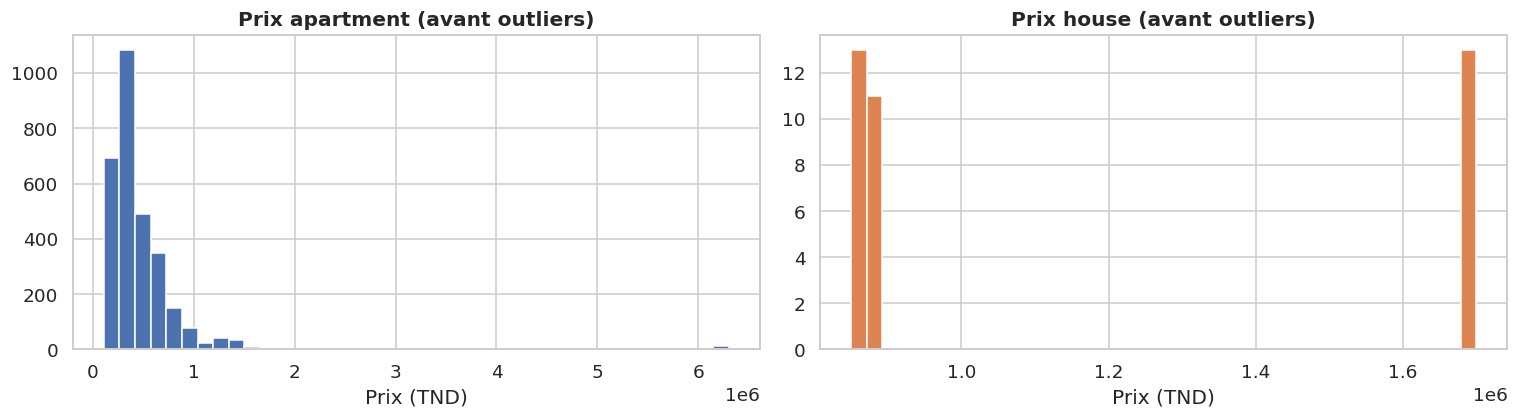

✅ Outliers prix supprimés :    14 → 2,991 restantes

Stats prix après filtrage :
                    min       25%       50%        75%        max
property_type                                                    
apartment     111111.00 275000.00 380000.00  539994.00 2700000.00
house         850000.00 850000.00 880000.00 1700000.00 1700000.00


In [12]:
# ══════════════════════════════════════════════════
# ÉTAPE 5 — OUTLIERS DE PRIX PAR TYPE DE BIEN
# ══════════════════════════════════════════════════

# Visualisation avant filtrage
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, ptype, c in zip(axes, ['apartment','house'], ['#4C72B0','#DD8452']):
    sub = df[df['property_type']==ptype]['price_tnd']
    ax.hist(sub, bins=40, color=c, edgecolor='white')
    ax.set_title(f'Prix {ptype} (avant outliers)', fontweight='bold')
    ax.set_xlabel('Prix (TND)')
plt.tight_layout(); plt.show()

# Seuils métier réalistes Tunisie 2024–2025
PRICE_BOUNDS = {
    'apartment': (80_000,   5_000_000),
    'house':     (100_000, 10_000_000),
}

before = len(df)
keep = []
for ptype, (lo, hi) in PRICE_BOUNDS.items():
    sub = df[df['property_type'] == ptype]
    keep.append(sub[sub['price_tnd'].between(lo, hi)])
df = pd.concat(keep, ignore_index=True)
stats['apres_outliers'] = len(df)

print(f'✅ Outliers prix supprimés : {before - len(df):>5} → {len(df):,} restantes')
print()
print('Stats prix après filtrage :')
print(df.groupby('property_type')['price_tnd'].describe()[['min','25%','50%','75%','max']])

In [13]:
# ══════════════════════════════════════════════════
# ÉTAPE 6 — NETTOYAGE SURFACE
# ══════════════════════════════════════════════════
df['surface'] = pd.to_numeric(df['surface'], errors='coerce')

# Correction typos ×10 : surface irréaliste pour appartements > 2000 m²
mask_typo_apt = (df['property_type']=='apartment') & (df['surface'] > 2000)
df.loc[mask_typo_apt, 'surface'] = df.loc[mask_typo_apt, 'surface'] / 10
print(f'Typos surface appartements corrigées : {mask_typo_apt.sum()}')

# Correction typos ×10 : maisons/villas > 5000 m²
mask_typo_house = (df['property_type']=='house') & (df['surface'] > 5000)
df.loc[mask_typo_house, 'surface'] = df.loc[mask_typo_house, 'surface'] / 10
print(f'Typos surface maisons corrigées      : {mask_typo_house.sum()}')

# Invalider surfaces hors bornes
SURFACE_BOUNDS = {'apartment': (20, 1000), 'house': (50, 5000)}
for ptype, (lo, hi) in SURFACE_BOUNDS.items():
    mask_bad = (df['property_type']==ptype) & ((df['surface'] < lo) | (df['surface'] > hi))
    df.loc[mask_bad, 'surface'] = np.nan
    print(f'Surfaces invalides {ptype} → NaN : {mask_bad.sum()}')

# Imputation par médiane (property_type × rooms)
df['surface'] = df.groupby(['property_type','rooms'])['surface'] \
                  .transform(lambda x: x.fillna(x.median()))
df['surface'] = df.groupby('property_type')['surface'] \
                  .transform(lambda x: x.fillna(x.median()))
df['surface'].fillna(df['surface'].median(), inplace=True)

print(f'\nSurface NaN restants : {df["surface"].isna().sum()}')
print(df.groupby('property_type')['surface'].describe()[['min','50%','max']])

Typos surface appartements corrigées : 12
Typos surface maisons corrigées      : 0
Surfaces invalides apartment → NaN : 1
Surfaces invalides house → NaN : 0

Surface NaN restants : 0
                 min    50%    max
property_type                     
apartment      40.00 124.85 522.70
house         344.70 350.95 355.00


In [14]:
# ══════════════════════════════════════════════════
# ÉTAPE 7 — NETTOYAGE ROOMS / BEDROOMS / BATHROOMS
# ══════════════════════════════════════════════════

# Rooms
df['rooms'] = pd.to_numeric(df['rooms'], errors='coerce')
df.loc[(df['rooms'] < 1) | (df['rooms'] > 10), 'rooms'] = np.nan
df['rooms'] = df.groupby('property_type')['rooms'].transform(lambda x: x.fillna(x.median()))
df['rooms'].fillna(df['rooms'].median(), inplace=True)
df['rooms'] = df['rooms'].round(0)

# Bedrooms : 'rangement' → NaN, puis cast numérique
before_bed_nan = df['bedrooms'].isna().sum()
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')  # 'rangement' → NaN
after_bed_nan  = df['bedrooms'].isna().sum()
print(f'bedrooms "rangement" → NaN : {after_bed_nan - before_bed_nan} supplémentaires')

df.loc[(df['bedrooms'] < 0) | (df['bedrooms'] > 10), 'bedrooms'] = np.nan
# Imputation : appartement → rooms-1 ; maison/villa → rooms
mask_apt   = df['property_type'] == 'apartment'
mask_house = df['property_type'] == 'house'
df.loc[df['bedrooms'].isna() & mask_apt,   'bedrooms'] = (df.loc[df['bedrooms'].isna() & mask_apt,   'rooms'] - 1).clip(lower=0)
df.loc[df['bedrooms'].isna() & mask_house, 'bedrooms'] = df.loc[df['bedrooms'].isna() & mask_house, 'rooms']
df['bedrooms'].fillna(df['bedrooms'].median(), inplace=True)

# Bathrooms : 100% NaN → estimé
df['bathrooms'] = np.where(
    df['property_type'] == 'house',
    (df['bedrooms'] / 2).clip(lower=1).round(0),
    (df['bedrooms'] / 2).clip(lower=1).round(0)
)

print(f'rooms NaN     : {df["rooms"].isna().sum()}')
print(f'bedrooms NaN  : {df["bedrooms"].isna().sum()}')
print(f'bathrooms NaN : {df["bathrooms"].isna().sum()}')
print()
print(df.groupby('property_type')[['rooms','bedrooms','bathrooms']].median())

bedrooms "rangement" → NaN : 468 supplémentaires
rooms NaN     : 0
bedrooms NaN  : 0
bathrooms NaN : 0

               rooms  bedrooms  bathrooms
property_type                            
apartment       2.00      1.00       1.00
house           4.00      4.00       2.00


In [15]:
# ══════════════════════════════════════════════════
# ÉTAPE 8 — EXTRACTION DE LA VILLE
# (municipality = 'Tunisie' partout → on mine le titre + la description)
# ══════════════════════════════════════════════════

CITY_PATTERNS = [
    ('Sidi Bou Said',       ['sidi bou said', 'sidi bousaid']),
    ('Gammarth',            ['gammarth']),
    ('Jardins de Carthage', ['jardins de carthage', 'jdc']),
    ('Carthage',            ['carthage']),
    ('La Marsa',            ['la marsa']),
    ('Berges du Lac',       ['berges du lac', 'lac 2', 'lac2']),
    ('Ariana',              ['ariana']),
    ('La Soukra',           ['la soukra', 'soukra', 'nouvelle soukra']),
    ('Ain Zaghouan',        ['ain zaghouan', 'zaghouan']),
    ('El Menzah',           ['el menzah', 'menzah']),
    ('Ennasr',              ['ennasr', 'el nasr']),
    ('El Aouina',           ['el aouina', "l'aouina", 'aouina']),
    ('Hammamet',            ['hammamet', 'mrezgua', 'mrezga', 'kantaoui']),
    ('Nabeul',              ['nabeul', 'kelibia', 'cap bon']),
    ('Sousse',              ['sousse', 'sahloul', 'khezama', 'errayhane']),
    ('Sfax',                ['sfax']),
    ('Monastir',            ['monastir', 'skanes']),
    ('Kairouan',            ['kairouan']),
    ('Manouba',             ['manouba', 'borj louzir']),
    ('Tunis',               ['centre ville tunis', 'centre-ville', 'bab el', 'médina tunis']),
    ('Ben Arous',           ['ben arous', 'megrine', 'ezzahra', 'rades', 'hammam lif']),
    ('Djerba',              ['djerba', 'midoun', 'houmt souk']),
    ('Bizerte',             ['bizerte']),
    ('Tunis',               ['tunis']),  # fallback general
]

def extract_city(row):
    text = (str(row.get('title', '')) + ' ' + str(row.get('description', ''))).lower()
    for city, patterns in CITY_PATTERNS:
        for p in patterns:
            if p in text:
                return city
    return 'Autre'

df['city'] = df.apply(extract_city, axis=1)
coverage = (df['city'] != 'Autre').mean() * 100
print(f'Couverture ville : {coverage:.1f}%')
print()
print('Distribution des villes :')
print(df['city'].value_counts())

Couverture ville : 72.7%

Distribution des villes :
city
Autre                  817
La Soukra              341
Jardins de Carthage    313
Sousse                 285
Hammamet               196
La Marsa               195
El Aouina              158
Kairouan               142
Nabeul                  93
Berges du Lac           84
Tunis                   77
Ennasr                  73
Ain Zaghouan            59
Ariana                  39
Carthage                37
Gammarth                20
Ben Arous               20
Sidi Bou Said           14
Sfax                    12
Manouba                  8
Bizerte                  8
Name: count, dtype: int64


In [16]:
# ══════════════════════════════════════════════════
# ÉTAPE 8b — SOUS-TYPE DE BIEN (villa / maison / apartment)
# Extraction depuis le titre
# ══════════════════════════════════════════════════

def extract_subtype(row):
    if row['property_type'] == 'apartment':
        return 'apartment'
    t = str(row['title']).lower()
    if any(k in t for k in ['villa','duplex','triplex','houch','riad','maison arabe','plain pied']):
        return 'villa'
    return 'maison'

df['property_subtype'] = df.apply(extract_subtype, axis=1)
print('Sous-types :', df['property_subtype'].value_counts().to_dict())

Sous-types : {'apartment': 2954, 'villa': 37}


In [17]:
# ══════════════════════════════════════════════════
# ÉTAPE 9 — SUPPRESSION DES DOUBLONS
# ══════════════════════════════════════════════════

before = len(df)
df.drop_duplicates(subset=['id'], inplace=True)
print(f'Doublons id supprimés      : {before - len(df)}')

before = len(df)
df.drop_duplicates(
    subset=['price_tnd', 'surface', 'rooms', 'property_type', 'city'],
    inplace=True
)
stats['apres_doublons'] = len(df)
print(f'Doublons features supprimés: {before - len(df)} → {len(df):,} restantes')

Doublons id supprimés      : 0
Doublons features supprimés: 1286 → 1,705 restantes


In [18]:
# ══════════════════════════════════════════════════
# RÉSUMÉ COMPLET DU NETTOYAGE
# ══════════════════════════════════════════════════
print('='*58)
print('          RÉSUMÉ DATA CLEANING')
print('='*58)
print(f'  Lignes initiales                : {stats["initial"]:>6,}')
print(f'  Après suppression terrains      : {stats["apres_land"]:>6,}')
print(f'  Après suppression locations     : {stats["apres_rent"]:>6,}')
print(f'  Après suppression prix manquant : {stats["apres_prix_nan"]:>6,}')
print(f'  Après outliers prix             : {stats["apres_outliers"]:>6,}')
print(f'  Après doublons                  : {stats["apres_doublons"]:>6,}')
print(f'  ── Lignes finales               : {len(df):>6,}')
print(f'  ── Supprimées total             : {stats["initial"] - len(df):>6,}')
print('='*58)
print(f'  NaN restants                    : {df.isnull().sum().sum():>6}')
print('='*58)
print()
print('Distribution finale :')
print('  property_type    :', df['property_type'].value_counts().to_dict())
print('  property_subtype :', df['property_subtype'].value_counts().to_dict())
print('  Top villes :')
print(df['city'].value_counts().head(10))

          RÉSUMÉ DATA CLEANING
  Lignes initiales                :  4,000
  Après suppression terrains      :  4,000
  Après suppression locations     :  4,000
  Après suppression prix manquant :  3,005
  Après outliers prix             :  2,991
  Après doublons                  :  1,705
  ── Lignes finales               :  1,705
  ── Supprimées total             :  2,295
  NaN restants                    :     16

Distribution finale :
  property_type    : {'apartment': 1690, 'house': 15}
  property_subtype : {'apartment': 1690, 'villa': 15}
  Top villes :
city
Autre                  471
La Soukra              187
Jardins de Carthage    180
Sousse                 178
Hammamet               146
La Marsa               115
El Aouina              108
Berges du Lac           71
Ennasr                  51
Ain Zaghouan            29
Name: count, dtype: int64


## 📊 5. Analyse Exploratoire Post-Cleaning

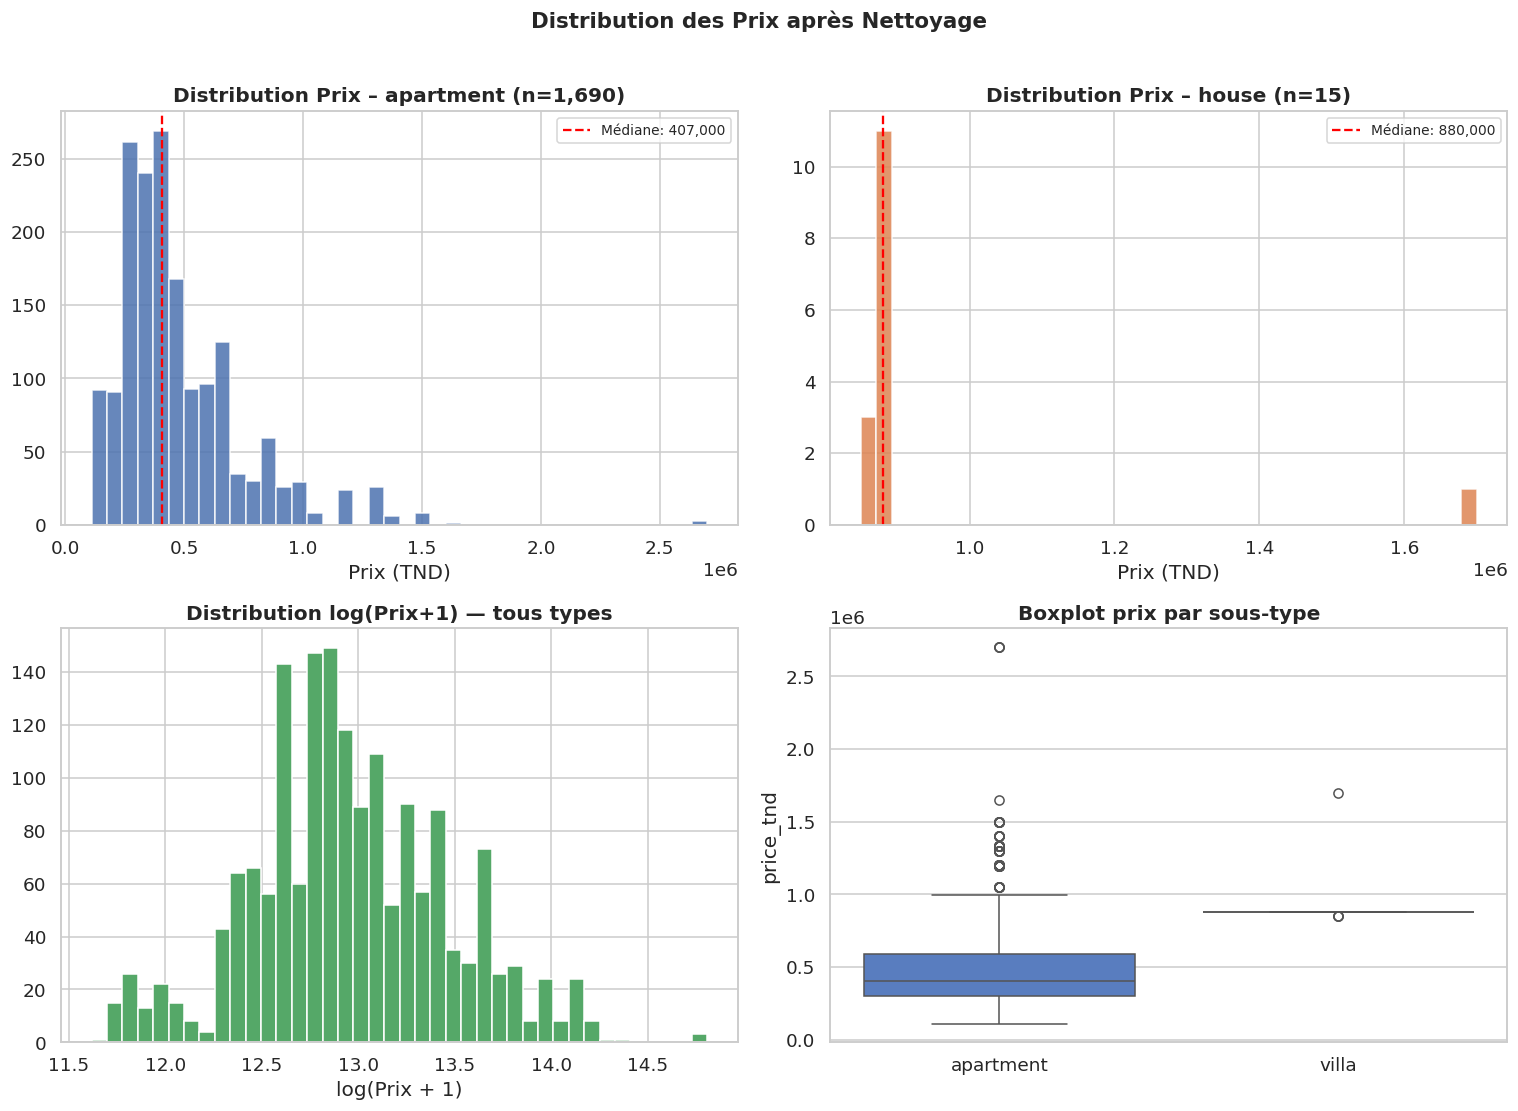

In [19]:
# Distribution prix après nettoyage
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogramme prix
for ax, ptype, c in zip([axes[0,0], axes[0,1]], ['apartment','house'], ['#4C72B0','#DD8452']):
    sub = df[df['property_type']==ptype]['price_tnd']
    ax.hist(sub, bins=40, color=c, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution Prix – {ptype} (n={len(sub):,})', fontweight='bold')
    ax.set_xlabel('Prix (TND)')
    q25, med, q75 = sub.quantile([.25,.5,.75])
    ax.axvline(med, color='red', lw=1.5, linestyle='--', label=f'Médiane: {med:,.0f}')
    ax.legend(fontsize=9)

# Log prix
axes[1,0].hist(np.log1p(df['price_tnd']), bins=40, color='#55A868', edgecolor='white')
axes[1,0].set_title('Distribution log(Prix+1) — tous types', fontweight='bold')
axes[1,0].set_xlabel('log(Prix + 1)')

# Boxplot par sous-type
order = [s for s in ['apartment','maison','villa'] if s in df['property_subtype'].unique()]
sns.boxplot(data=df, x='property_subtype', y='price_tnd', order=order,
            palette='muted', ax=axes[1,1])
axes[1,1].set_title('Boxplot prix par sous-type', fontweight='bold')
axes[1,1].set_xlabel('')

plt.suptitle('Distribution des Prix après Nettoyage', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

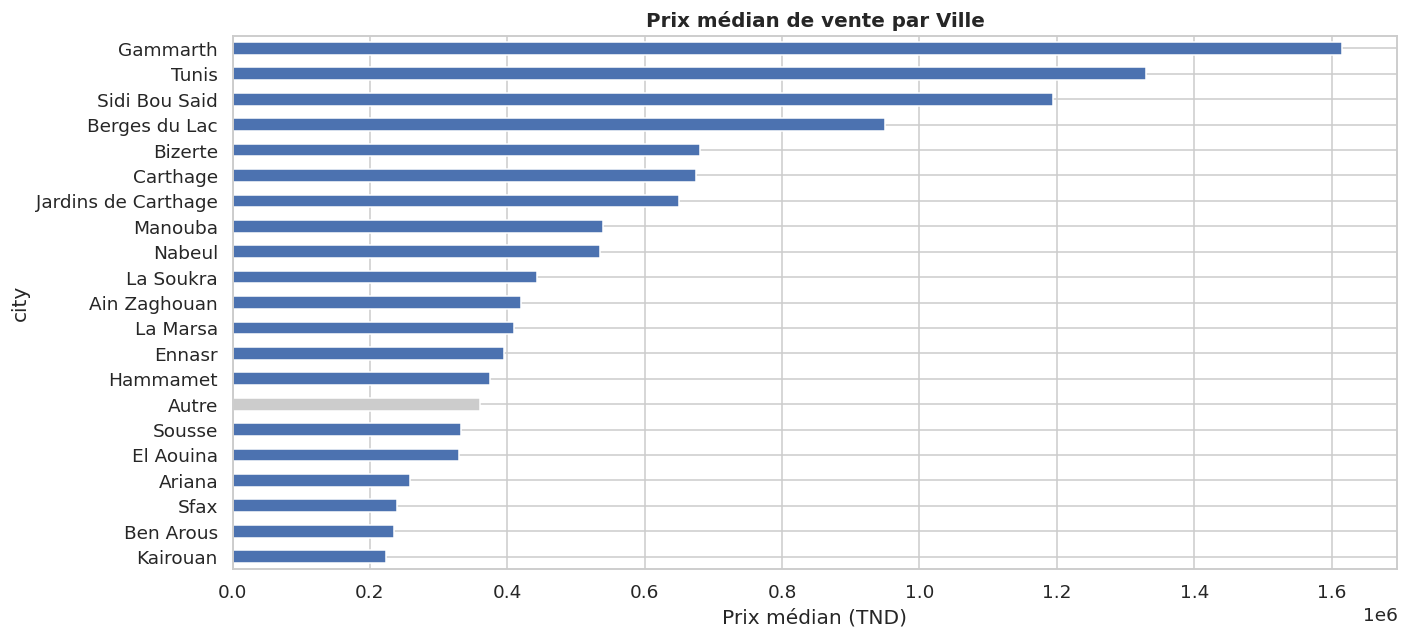

In [20]:
# Prix médian par ville
fig, ax = plt.subplots(figsize=(13, 6))
city_med = df.groupby('city')['price_tnd'].median().sort_values(ascending=True)
colors_bar = ['#4C72B0' if c != 'Autre' else '#cccccc' for c in city_med.index]
city_med.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
ax.set_title('Prix médian de vente par Ville', fontweight='bold', fontsize=13)
ax.set_xlabel('Prix médian (TND)')
plt.tight_layout(); plt.show()

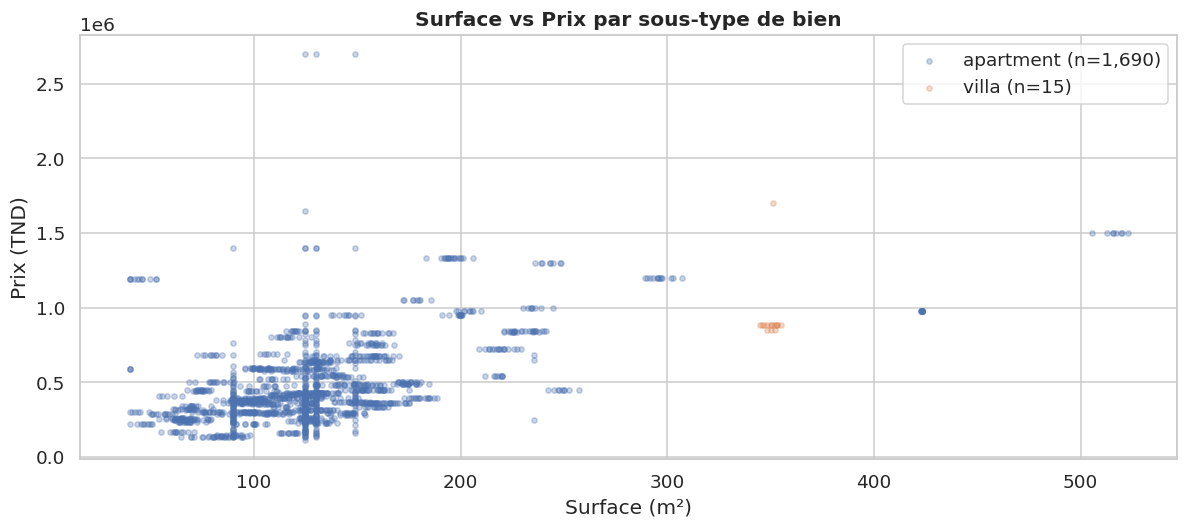

In [21]:
# Surface vs Prix
fig, ax = plt.subplots(figsize=(11, 5))
colors_map = {'apartment': '#4C72B0', 'villa': '#DD8452', 'maison': '#55A868'}
for stype, color in colors_map.items():
    sub = df[df['property_subtype']==stype]
    if len(sub) > 0:
        ax.scatter(sub['surface'], sub['price_tnd'], alpha=0.3, s=12,
                   color=color, label=f'{stype} (n={len(sub):,})')
ax.set_xlabel('Surface (m²)')
ax.set_ylabel('Prix (TND)')
ax.set_title('Surface vs Prix par sous-type de bien', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

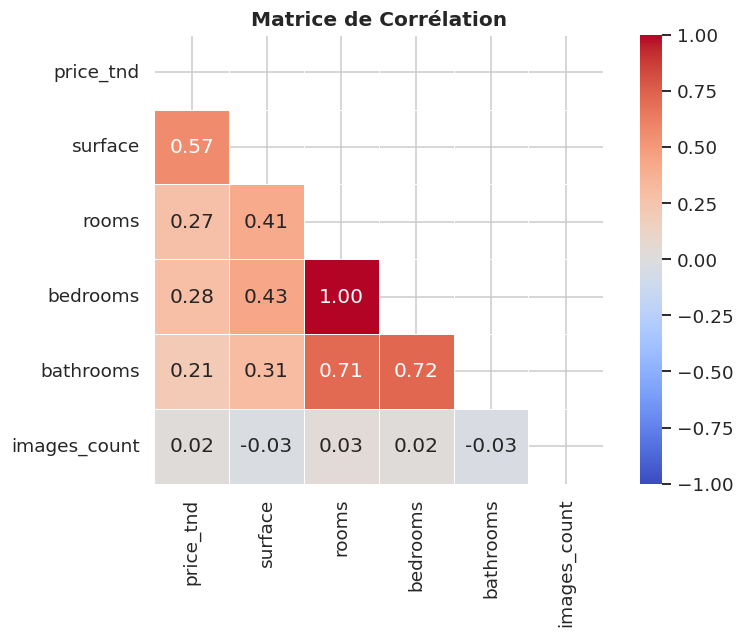

In [22]:
# Matrice de corrélation
num_cols = ['price_tnd','surface','rooms','bedrooms','bathrooms','images_count']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, square=True, vmin=-1, vmax=1)
ax.set_title('Matrice de Corrélation', fontweight='bold')
plt.tight_layout(); plt.show()

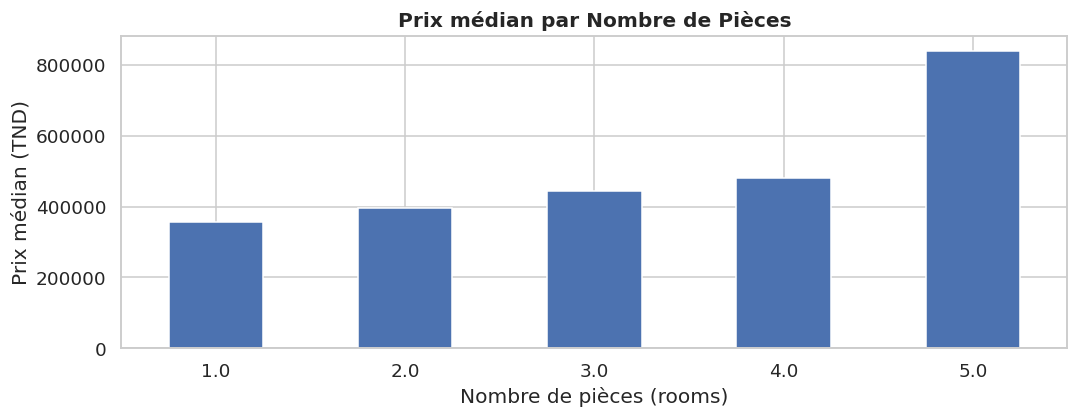

In [23]:
# Prix moyen par nombre de pièces
fig, ax = plt.subplots(figsize=(10, 4))
rooms_price = df.groupby('rooms')['price_tnd'].median()
rooms_price.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Prix médian par Nombre de Pièces', fontweight='bold')
ax.set_xlabel('Nombre de pièces (rooms)')
ax.set_ylabel('Prix médian (TND)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## ⚙️ 6. Feature Engineering

In [24]:
df_ml = df.copy()

# ── Sécurisation numérique ──────────────────────────────────────
for col in ['surface','rooms','bedrooms','bathrooms','images_count']:
    df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')
    df_ml[col].fillna(df_ml[col].median(), inplace=True)
    df_ml[col] = df_ml[col].clip(lower=0)

# ── Features dérivées ───────────────────────────────────────────
df_ml['log_surface']    = np.log1p(df_ml['surface'])
df_ml['rooms_per_m2']   = (df_ml['rooms'] / df_ml['surface'].clip(lower=1)).clip(lower=0)
df_ml['price_per_m2']   = df_ml['price_tnd'] / df_ml['surface'].clip(lower=1)  # info seulement

# Ratios surface/rooms (indicateur d'espace moyen par pièce)
df_ml['m2_per_room']    = (df_ml['surface'] / df_ml['rooms'].clip(lower=1)).clip(lower=0)

# ── Encodage property_type ───────────────────────────────────────
le = LabelEncoder()
df_ml['property_type_enc']    = le.fit_transform(df_ml['property_type'].astype(str))
df_ml['property_subtype_enc'] = le.fit_transform(df_ml['property_subtype'].astype(str))

# ── Target encoding ville ────────────────────────────────────────
city_mean  = df_ml.groupby('city')['price_tnd'].mean()
city_med   = df_ml.groupby('city')['price_tnd'].median()
city_count = df_ml['city'].value_counts()

df_ml['city_mean_enc']  = df_ml['city'].map(city_mean).fillna(df_ml['price_tnd'].mean())
df_ml['city_med_enc']   = df_ml['city'].map(city_med).fillna(df_ml['price_tnd'].median())
df_ml['city_freq_enc']  = df_ml['city'].map(city_count).fillna(1)

# ── Target encoding sous-type ────────────────────────────────────
sub_mean = df_ml.groupby('property_subtype')['price_tnd'].mean()
df_ml['subtype_price_enc'] = df_ml['property_subtype'].map(sub_mean).fillna(df_ml['price_tnd'].mean())

# ── Features selection finale ────────────────────────────────────
FEATURES = [
    'surface',
    'log_surface',
    'rooms',
    'bedrooms',
    'bathrooms',
    'rooms_per_m2',
    'm2_per_room',
    'images_count',
    'property_type_enc',
    'property_subtype_enc',
    'city_mean_enc',
    'city_med_enc',
    'city_freq_enc',
    'subtype_price_enc',
]
TARGET = 'price_tnd'

X = df_ml[FEATURES].copy()
y = df_ml[TARGET].copy()

# Filet de sécurité NaN
if X.isnull().sum().sum() > 0:
    print('⚠️  NaN détectés, imputation médiane :')
    for col in X.columns:
        if X[col].isnull().any():
            med = X[col].median()
            X[col].fillna(med if not np.isnan(med) else 0, inplace=True)
            print(f'   {col} → {med:.2f}')

assert X.isnull().sum().sum() == 0, '❌ NaN dans X!'
assert y.isnull().sum() == 0,       '❌ NaN dans y!'

print(f'✅ Dataset ML prêt : X{X.shape} | y{y.shape}')
print(f'   {len(FEATURES)} features : {FEATURES}')

✅ Dataset ML prêt : X(1705, 14) | y(1705,)
   14 features : ['surface', 'log_surface', 'rooms', 'bedrooms', 'bathrooms', 'rooms_per_m2', 'm2_per_room', 'images_count', 'property_type_enc', 'property_subtype_enc', 'city_mean_enc', 'city_med_enc', 'city_freq_enc', 'subtype_price_enc']


## ✂️ 7. Train / Test Split

Train : 1,364 (80.0%)
Test  : 341  (20.0%)


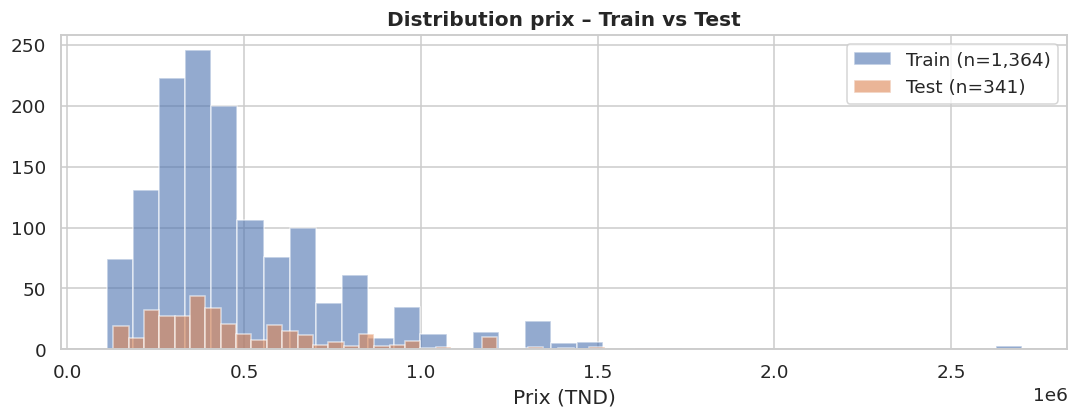

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'Train : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test  : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_train, bins=35, alpha=0.6, label=f'Train (n={len(y_train):,})',
        color='#4C72B0', edgecolor='white')
ax.hist(y_test,  bins=35, alpha=0.6, label=f'Test (n={len(y_test):,})',
        color='#DD8452', edgecolor='white')
ax.set_title('Distribution prix – Train vs Test', fontweight='bold')
ax.set_xlabel('Prix (TND)')
ax.legend()
plt.tight_layout(); plt.show()

## 🌲 8. Modèle 1 — Random Forest Regressor

In [26]:
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=25,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test.clip(lower=1))) * 100

print('='*50)
print('   RANDOM FOREST — RÉSULTATS TEST')
print('='*50)
print(f'  MAE  : {mae_rf:>12,.0f} TND')
print(f'  RMSE : {rmse_rf:>12,.0f} TND')
print(f'  R²   : {r2_rf:>12.4f}')
print(f'  MAPE : {mape_rf:>11.2f} %')
print('='*50)

   RANDOM FOREST — RÉSULTATS TEST
  MAE  :       72,751 TND
  RMSE :      129,236 TND
  R²   :       0.7822
  MAPE :       18.36 %


In [27]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rf = cross_val_score(rf_model, X, y, cv=cv, scoring='r2', n_jobs=-1)
print(f'CV R² Random Forest (5-fold) : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')
print(f'Scores par fold : {[round(s,4) for s in cv_rf]}')

CV R² Random Forest (5-fold) : 0.7769 ± 0.0332
Scores par fold : [np.float64(0.7814), np.float64(0.7365), np.float64(0.7639), np.float64(0.8366), np.float64(0.7661)]


## ⚡ 9. Modèle 2 — XGBoost Regressor

In [28]:
xgb_model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.80,
    colsample_bytree=0.80,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb   = r2_score(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test.clip(lower=1))) * 100

print('='*50)
print('   XGBOOST — RÉSULTATS TEST')
print('='*50)
print(f'  MAE  : {mae_xgb:>12,.0f} TND')
print(f'  RMSE : {rmse_xgb:>12,.0f} TND')
print(f'  R²   : {r2_xgb:>12.4f}')
print(f'  MAPE : {mape_xgb:>11.2f} %')
print('='*50)

   XGBOOST — RÉSULTATS TEST
  MAE  :       56,961 TND
  RMSE :      110,623 TND
  R²   :       0.8404
  MAPE :       14.44 %


In [29]:
cv_xgb = cross_val_score(xgb_model, X, y, cv=cv, scoring='r2', n_jobs=-1)
print(f'CV R² XGBoost (5-fold) : {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}')
print(f'Scores par fold : {[round(s,4) for s in cv_xgb]}')

CV R² XGBoost (5-fold) : 0.8646 ± 0.0297
Scores par fold : [np.float64(0.8408), np.float64(0.8635), np.float64(0.8285), np.float64(0.9136), np.float64(0.8765)]


## 📊 10. Évaluation Comparée & Visualisations

In [30]:
# Tableau comparatif
results = pd.DataFrame({
    'Modèle'     : ['Random Forest', 'XGBoost'],
    'MAE (TND)'  : [mae_rf,    mae_xgb],
    'RMSE (TND)' : [rmse_rf,   rmse_xgb],
    'R²'         : [r2_rf,     r2_xgb],
    'MAPE (%)'   : [mape_rf,   mape_xgb],
    'CV R² mean' : [cv_rf.mean(), cv_xgb.mean()],
    'CV R² std'  : [cv_rf.std(),  cv_xgb.std()],
}).set_index('Modèle')

display(
    results.style
    .highlight_min(subset=['MAE (TND)','RMSE (TND)','MAPE (%)'], color='#c6efce')
    .highlight_max(subset=['R²','CV R² mean'],                   color='#c6efce')
    .format({'MAE (TND)':'{:,.0f}','RMSE (TND)':'{:,.0f}',
             'R²':'{:.4f}','MAPE (%)':'{:.2f}',
             'CV R² mean':'{:.4f}','CV R² std':'{:.4f}'})
)

,MAE (TND),RMSE (TND),R²,MAPE (%),CV R² mean,CV R² std
Modèle,,,,,,
Random Forest,"72,751","129,236",0.7822,18.36,0.7769,0.0332
XGBoost,"56,961","110,623",0.8404,14.44,0.8646,0.0297


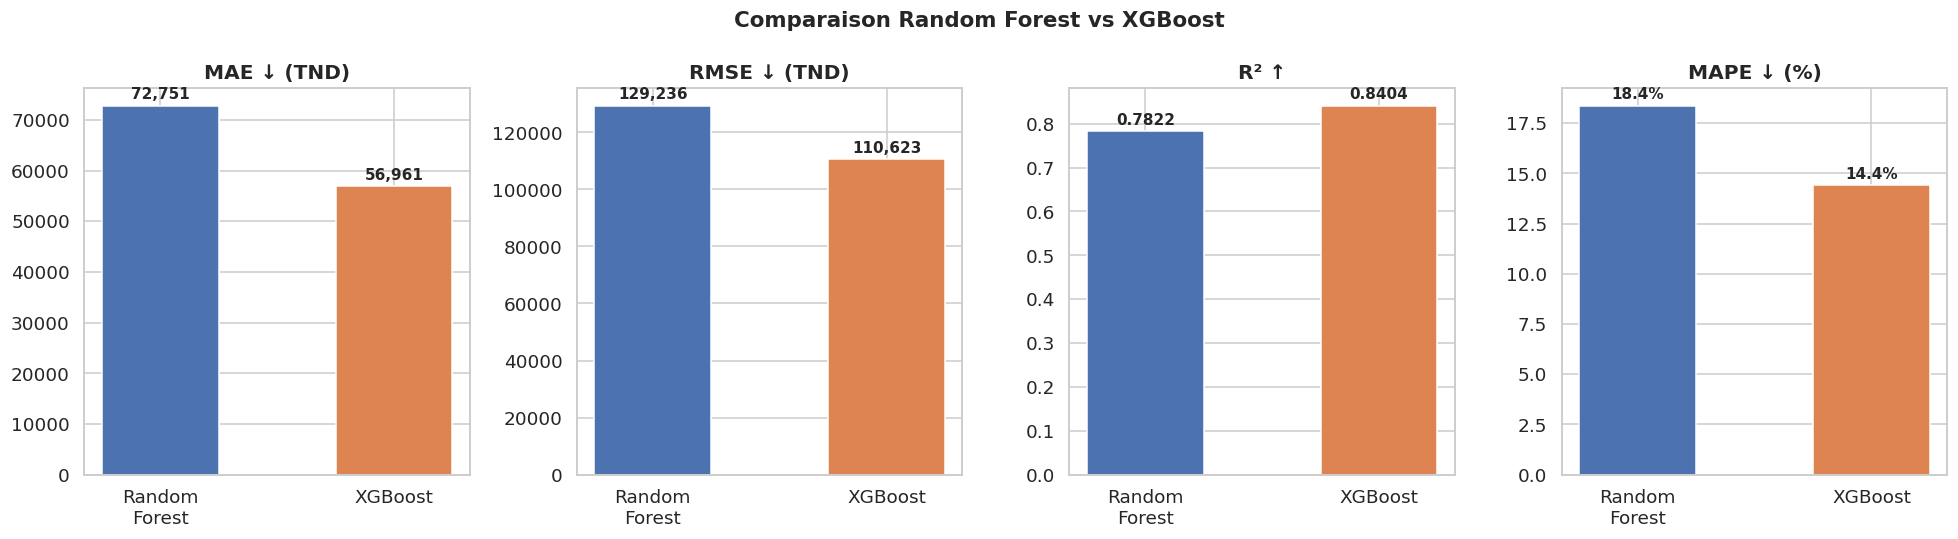

In [31]:
# Barres métriques
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
names  = ['Random\nForest', 'XGBoost']
colors = ['#4C72B0', '#DD8452']

for ax, vals, title, fmt in zip(
    axes,
    [[mae_rf,mae_xgb],[rmse_rf,rmse_xgb],[r2_rf,r2_xgb],[mape_rf,mape_xgb]],
    ['MAE ↓ (TND)','RMSE ↓ (TND)','R² ↑','MAPE ↓ (%)'],
    ['{:,.0f}','{:,.0f}','{:.4f}','{:.1f}%']
):
    bars = ax.bar(names, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                fmt.format(v), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Comparaison Random Forest vs XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

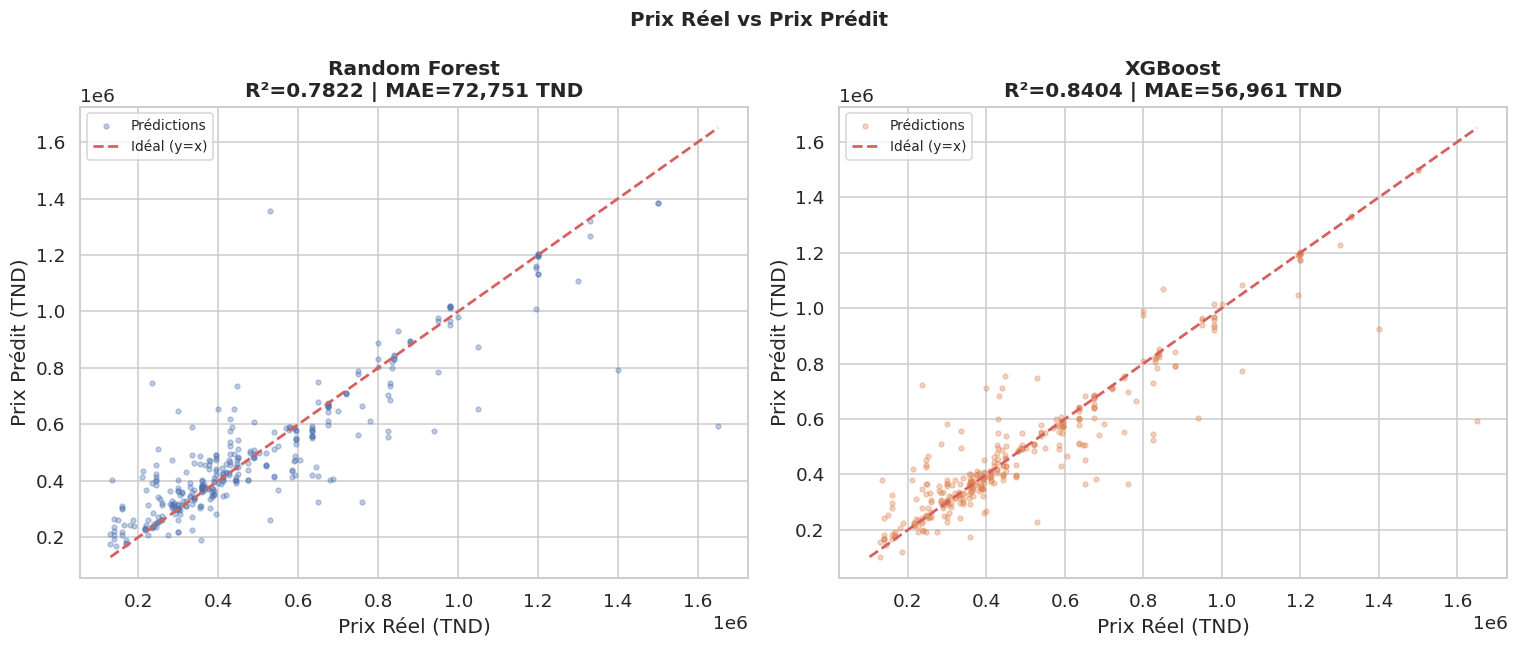

In [32]:
# Réel vs Prédit
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, y_pred, name, color, r2 in zip(
    axes,
    [y_pred_rf, y_pred_xgb],
    ['Random Forest', 'XGBoost'],
    colors,
    [r2_rf, r2_xgb]
):
    ax.scatter(y_test, y_pred, alpha=0.35, color=color, s=10, label='Prédictions')
    lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', lw=1.8, label='Idéal (y=x)')
    ax.set_title(f'{name}\nR²={r2:.4f} | MAE={mean_absolute_error(y_test,y_pred):,.0f} TND',
                 fontweight='bold')
    ax.set_xlabel('Prix Réel (TND)')
    ax.set_ylabel('Prix Prédit (TND)')
    ax.legend(fontsize=9)
plt.suptitle('Prix Réel vs Prix Prédit', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

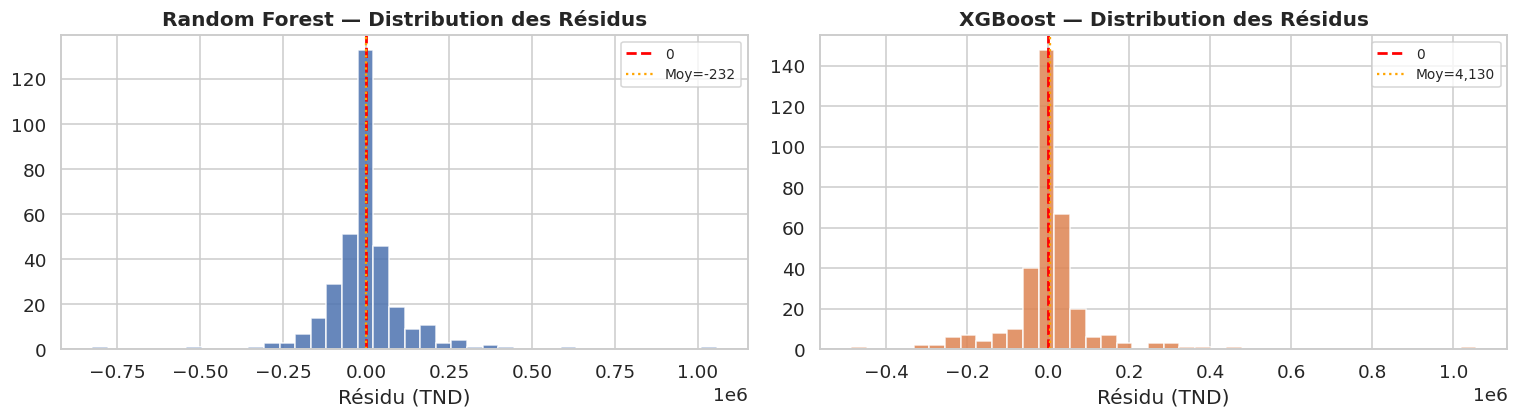

In [33]:
# Résidus
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, y_pred, name, color in zip(
    axes, [y_pred_rf,y_pred_xgb], ['Random Forest','XGBoost'], colors
):
    resid = y_test - y_pred
    ax.hist(resid, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', lw=1.8, linestyle='--', label='0')
    ax.axvline(resid.mean(), color='orange', lw=1.5, linestyle=':',
               label=f'Moy={resid.mean():,.0f}')
    ax.set_title(f'{name} — Distribution des Résidus', fontweight='bold')
    ax.set_xlabel('Résidu (TND)')
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

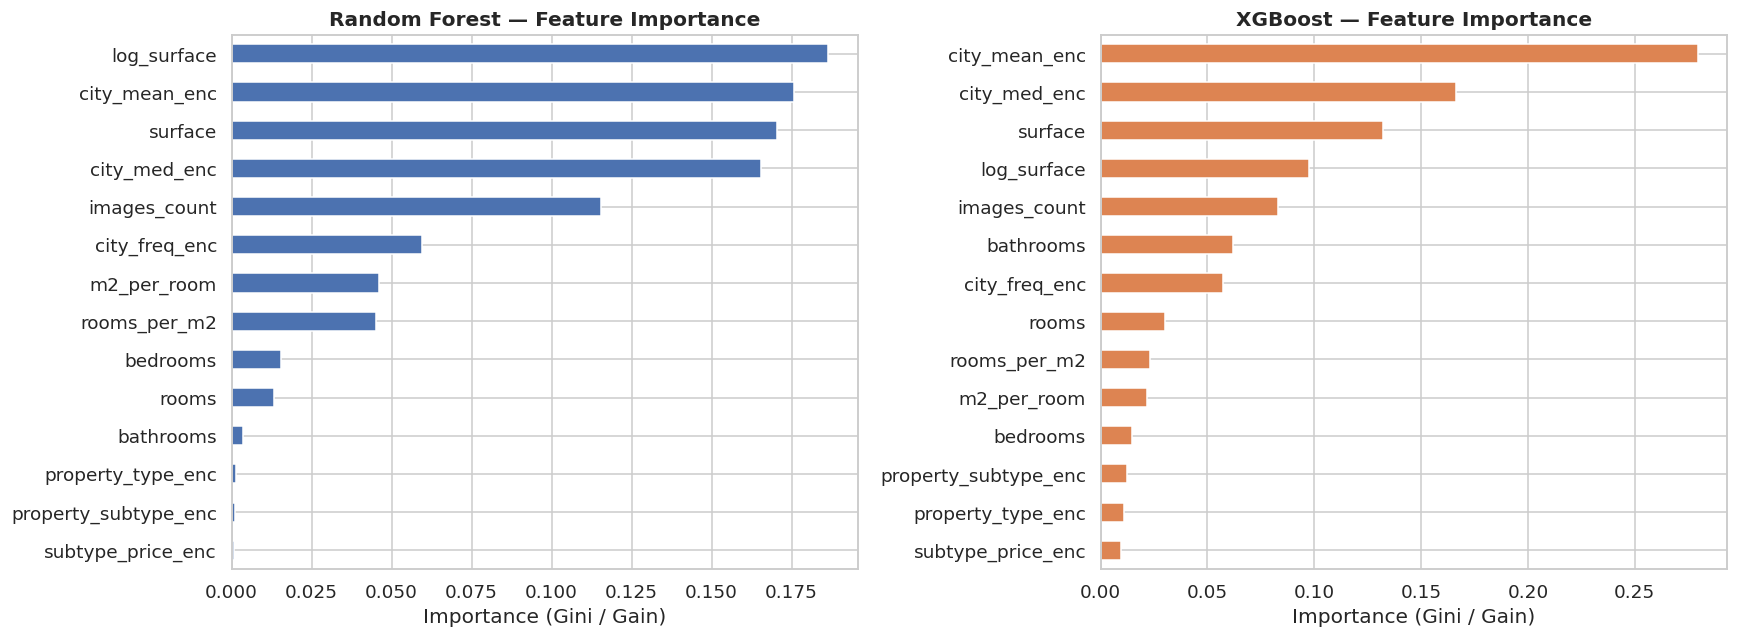

In [34]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, name, color in zip(
    axes, [rf_model,xgb_model], ['Random Forest','XGBoost'], colors
):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{name} — Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance (Gini / Gain)')
plt.tight_layout(); plt.show()

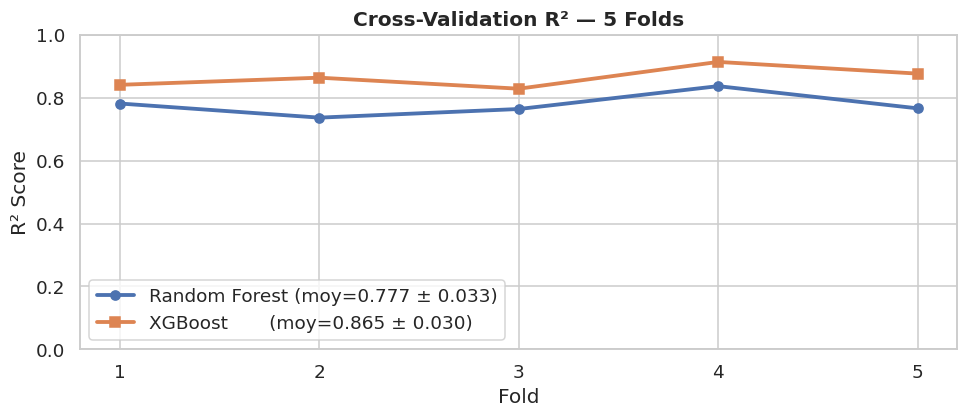

In [35]:
# Cross-validation comparée
fig, ax = plt.subplots(figsize=(9, 4))
folds = range(1, len(cv_rf)+1)
ax.plot(folds, cv_rf,  'o-', color='#4C72B0', lw=2.5,
        label=f'Random Forest (moy={cv_rf.mean():.3f} ± {cv_rf.std():.3f})')
ax.plot(folds, cv_xgb, 's-', color='#DD8452', lw=2.5,
        label=f'XGBoost       (moy={cv_xgb.mean():.3f} ± {cv_xgb.std():.3f})')
ax.set_xlabel('Fold')
ax.set_ylabel('R² Score')
ax.set_title('Cross-Validation R² — 5 Folds', fontweight='bold')
ax.set_ylim(0, 1)
ax.set_xticks(list(folds))
ax.legend()
plt.tight_layout(); plt.show()

## 🔮 11. Prédiction sur un Nouveau Bien

In [36]:
def predict_price(surface, rooms, bedrooms,
                  property_type, property_subtype, city, images_count=8):
    """
    Prédit le prix de vente avec Random Forest + XGBoost.

    property_type    : 'apartment' | 'house'
    property_subtype : 'apartment' | 'maison' | 'villa'
    city             : ex. 'La Marsa', 'Hammamet', 'Sousse', 'Ariana'...
    """
    # Re-fit encoders sur df_ml courant
    le_type    = LabelEncoder().fit(df_ml['property_type'].astype(str))
    le_sub     = LabelEncoder().fit(df_ml['property_subtype'].astype(str))
    c_mean_map = df_ml.groupby('city')['price_tnd'].mean().to_dict()
    c_med_map  = df_ml.groupby('city')['price_tnd'].median().to_dict()
    c_cnt_map  = df_ml['city'].value_counts().to_dict()
    s_mean_map = df_ml.groupby('property_subtype')['price_tnd'].mean().to_dict()
    gm = df_ml['price_tnd'].mean()

    bathrooms    = max(1, round(bedrooms / 2))
    log_surf     = np.log1p(surface)
    rpm          = rooms / max(surface, 1)
    m2_pr        = surface / max(rooms, 1)
    try: ptype_enc = le_type.transform([property_type])[0]
    except: ptype_enc = 0
    try: stype_enc = le_sub.transform([property_subtype])[0]
    except: stype_enc = 0
    city_m  = c_mean_map.get(city, gm)
    city_md = c_med_map.get(city, gm)
    city_f  = c_cnt_map.get(city, 1)
    sub_m   = s_mean_map.get(property_subtype, gm)

    X_new = pd.DataFrame([{
        'surface': surface, 'log_surface': log_surf,
        'rooms': rooms, 'bedrooms': bedrooms, 'bathrooms': bathrooms,
        'rooms_per_m2': rpm, 'm2_per_room': m2_pr,
        'images_count': images_count,
        'property_type_enc': ptype_enc, 'property_subtype_enc': stype_enc,
        'city_mean_enc': city_m, 'city_med_enc': city_md,
        'city_freq_enc': city_f, 'subtype_price_enc': sub_m
    }])

    p_rf  = rf_model.predict(X_new)[0]
    p_xgb = xgb_model.predict(X_new)[0]
    ens   = (p_rf + p_xgb) / 2

    print(f'\n🏠 [{property_subtype.upper()}] {surface} m² | {rooms} pièces | {city}')
    print(f'   Random Forest  : {p_rf:>12,.0f} TND')
    print(f'   XGBoost        : {p_xgb:>12,.0f} TND')
    print(f'   Ensemble (moy) : {ens:>12,.0f} TND')
    return {'RF': p_rf, 'XGB': p_xgb, 'Ensemble': ens}

# ── Exemples de prédiction ────────────────────────────────────────
predict_price(100, 2, 2, 'apartment', 'apartment', 'La Soukra')
predict_price(130, 3, 3, 'apartment', 'apartment', 'Ariana')
predict_price(95,  2, 2, 'apartment', 'apartment', 'Sousse')
predict_price(200, 3, 3, 'apartment', 'apartment', 'Carthage')
predict_price(350, 4, 4, 'house',     'villa',     'La Marsa')
predict_price(250, 4, 4, 'house',     'villa',     'Hammamet')
predict_price(180, 3, 3, 'house',     'maison',    'Nabeul')


🏠 [APARTMENT] 100 m² | 2 pièces | La Soukra
   Random Forest  :      440,108 TND
   XGBoost        :      389,869 TND
   Ensemble (moy) :      414,989 TND

🏠 [APARTMENT] 130 m² | 3 pièces | Ariana
   Random Forest  :      279,845 TND
   XGBoost        :      216,895 TND
   Ensemble (moy) :      248,370 TND

🏠 [APARTMENT] 95 m² | 2 pièces | Sousse
   Random Forest  :      308,595 TND
   XGBoost        :      293,482 TND
   Ensemble (moy) :      301,039 TND

🏠 [APARTMENT] 200 m² | 3 pièces | Carthage
   Random Forest  :      837,846 TND
   XGBoost        :      827,415 TND
   Ensemble (moy) :      832,631 TND

🏠 [VILLA] 350 m² | 4 pièces | La Marsa
   Random Forest  :      884,327 TND
   XGBoost        :      848,254 TND
   Ensemble (moy) :      866,290 TND

🏠 [VILLA] 250 m² | 4 pièces | Hammamet
   Random Forest  :      742,263 TND
   XGBoost        :      542,699 TND
   Ensemble (moy) :      642,481 TND

🏠 [MAISON] 180 m² | 3 pièces | Nabeul
   Random Forest  :      598,426 TND
   XGB

{'RF': np.float64(598425.5163798106),
 'XGB': np.float32(556800.1),
 'Ensemble': np.float64(577612.8206899053)}

## 💾 12. Sauvegarde des Modèles

In [37]:
import joblib

joblib.dump(rf_model,  'rf_fidari.pkl')
joblib.dump(xgb_model, 'xgb_fidari.pkl')
df_ml.to_csv('fi_dari_cleaned.csv', index=False)

print('✅ Fichiers sauvegardés :')
print('   rf_fidari.pkl')
print('   xgb_fidari.pkl')
print('   fi_dari_cleaned.csv')

from google.colab import files
files.download('rf_fidari.pkl')
files.download('xgb_fidari.pkl')
files.download('fi_dari_cleaned.csv')

✅ Fichiers sauvegardés :
   rf_fidari.pkl
   xgb_fidari.pkl
   fi_dari_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📋 13. Rapport Final

In [38]:
best = 'XGBoost' if r2_xgb >= r2_rf else 'Random Forest'
best_r2  = max(r2_rf, r2_xgb)
best_mae = min(mae_rf, mae_xgb)

print('='*62)
print('        RAPPORT FINAL — Fi Dari Prix Prediction')
print('='*62)
print()
print('📊 DATASET')
print(f'  Lignes brutes                    : {stats["initial"]:>6,}')
print(f'  Lignes après nettoyage           : {len(df_ml):>6,}')
print(f'  Features utilisées               : {len(FEATURES):>6}')
print()
print('🧹 NETTOYAGE')
print(f'  Terrains supprimés               : {stats["initial"]-stats["apres_land"]:>6,}')
print(f'  Locations supprimées             : {stats["apres_land"]-stats["apres_rent"]:>6,}')
print(f'  Prix manquants/invalides         : {stats["apres_rent"]-stats["apres_prix_nan"]:>6,}')
print(f'  Outliers prix                    : {stats["apres_prix_nan"]-stats["apres_outliers"]:>6,}')
print(f'  Doublons                         : {stats["apres_outliers"]-stats["apres_doublons"]:>6,}')
print()
print('🤖 MODÈLES')
print(f'  Random Forest → R²={r2_rf:.4f} | MAE={mae_rf:>8,.0f} TND | MAPE={mape_rf:.1f}% | CV={cv_rf.mean():.4f}')
print(f'  XGBoost       → R²={r2_xgb:.4f} | MAE={mae_xgb:>8,.0f} TND | MAPE={mape_xgb:.1f}% | CV={cv_xgb.mean():.4f}')
print()
print(f'🏆 MEILLEUR MODÈLE : {best}')
print(f'   R² = {best_r2:.4f}  |  MAE = {best_mae:,.0f} TND')
print('='*62)

        RAPPORT FINAL — Fi Dari Prix Prediction

📊 DATASET
  Lignes brutes                    :  4,000
  Lignes après nettoyage           :  1,705
  Features utilisées               :     14

🧹 NETTOYAGE
  Terrains supprimés               :      0
  Locations supprimées             :      0
  Prix manquants/invalides         :    995
  Outliers prix                    :     14
  Doublons                         :  1,286

🤖 MODÈLES
  Random Forest → R²=0.7822 | MAE=  72,751 TND | MAPE=18.4% | CV=0.7769
  XGBoost       → R²=0.8404 | MAE=  56,961 TND | MAPE=14.4% | CV=0.8646

🏆 MEILLEUR MODÈLE : XGBoost
   R² = 0.8404  |  MAE = 56,961 TND
